# EGF Batch Analysis — H23 Ctrl vs 607-ko across time points
**Conditions:** H23 Ctrl EGF vs H23 607-ko EGF  
**Time points:** 5 min · 30 min · 60 min  
**Statistics:** Two-way ANOVA (genotype × timepoint) + Bonferroni post-hoc  
**Metrics:** C0/C1/C2 overlaps · distances to nucleus · distances to membrane

## 0 · Install packages (run once, then restart kernel)

In [1]:
import sys
!{sys.executable} -m pip install matplotlib seaborn pandas numpy scipy statsmodels pingouin --quiet
print('Done — restart the kernel if this was the first install.')

Done — restart the kernel if this was the first install.


## 1 · Imports & settings

In [2]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pingouin as pg
from pathlib import Path
from itertools import combinations

warnings.filterwarnings('ignore')

# ── paths ──────────────────────────────────────────────────────────────────
DATA_DIR  = Path(r'Z:/Marta/20260218/2026-02-18-Decon/results')
FIG_DIR   = Path(r'C:/Users/NIC-ADMIN4/Workspace/Jupyter/jupyter_napari/Marta/figures')
FIG_DIR.mkdir(exist_ok=True)

CELLS_CSV = DATA_DIR / 'EGF_batch_cell_summary.csv'

# ── plot style ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.15)
COND_PALETTE  = {'Ctrl': '#4C72B0', '607-ko': '#DD8452'}
TIME_ORDER    = ['5min', '30min', '60min']
DPI = 150

print('Ready.')

Ready.


## 2 · Load & parse data

In [3]:
cells_raw = pd.read_csv(CELLS_CSV)
print(f'Loaded {len(cells_raw):,} rows')

# ── parse genotype and timepoint from filename ─────────────────────────────
def parse_condition(fname):
    m = re.search(r'H23 (Ctrl|607-ko) EGF (\d+min)', str(fname))
    if m:
        return m.group(1), m.group(2)
    return None, None

cells_raw[['genotype', 'timepoint']] = cells_raw['file'].apply(
    lambda f: pd.Series(parse_condition(f))
)

# ── keep only H23 Ctrl / 607-ko EGF rows ──────────────────────────────────
cells = cells_raw.dropna(subset=['genotype', 'timepoint']).copy()
cells['timepoint'] = pd.Categorical(cells['timepoint'], categories=TIME_ORDER, ordered=True)

# unique identifier per cell: file + cell_id
cells['uid'] = cells['file'].astype(str) + '_cell' + cells['cell_id'].astype(str)

excluded = len(cells_raw) - len(cells)
print(f'Excluded {excluded} rows (non-EGF files)')
print(f'Retained {len(cells):,} cells')
print()
print(cells.groupby(['genotype', 'timepoint']).size().rename('n_cells').to_frame())

Loaded 1,499 rows
Excluded 15 rows (non-EGF files)
Retained 1,484 cells

                    n_cells
genotype timepoint         
607-ko   5min           201
         30min          191
         60min          198
Ctrl     5min           413
         30min          218
         60min          263


## 3 · Define analysis helpers

In [4]:
def run_two_way_anova(df, metric_col):
    """Two-way ANOVA (genotype × timepoint) using pingouin."""
    sub = df[['genotype', 'timepoint', metric_col]].dropna().copy()
    sub['timepoint'] = sub['timepoint'].astype(str)
    aov = pg.anova(data=sub, dv=metric_col, between=['genotype', 'timepoint'], detailed=True)
    return aov


def run_bonferroni(df, metric_col):
    """Pairwise Bonferroni-corrected t-tests between all 6 groups."""
    sub = df[['genotype', 'timepoint', metric_col]].dropna().copy()
    sub['group'] = sub['genotype'] + ' ' + sub['timepoint'].astype(str)
    gm = sub.groupby('group')[metric_col].mean()
    ph = pg.pairwise_tests(data=sub, dv=metric_col, between='group',
                           parametric=True, padjust='bonf')
    ph['mean(A)'] = ph['A'].map(gm).round(2)
    ph['mean(B)'] = ph['B'].map(gm).round(2)
    keep = ['A', 'B', 'mean(A)', 'mean(B)', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']
    keep = [c for c in keep if c in ph.columns]
    return ph[keep].sort_values('p_corr').reset_index(drop=True)


def sig_label(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'


def show_anova(aov):
    """Display ANOVA table with whichever columns are available."""
    want = ['Source', 'SS', 'DF', 'MS', 'F', 'p_unc', 'np2']
    cols = [c for c in want if c in aov.columns]
    display(aov[cols].round(4))


def _ci95_bounds(series):
    """Return (lower, upper) 95% CI of the mean using t-distribution."""
    from scipy import stats
    n = series.count()
    if n < 2:
        return series.mean(), series.mean()
    se = stats.sem(series.dropna())
    t  = stats.t.ppf(0.975, df=n-1)
    m  = series.mean()
    return m - t*se, m + t*se


def plot_metric(df, metric_col, ylabel, title, fname, bonf_df=None):
    """
    Grouped bar chart (mean ± 95% CI) per timepoint, coloured by genotype.
    Significant same-timepoint Bonferroni pairs are annotated.
    """
    sub = df[['genotype', 'timepoint', metric_col]].dropna().copy()
    sub['timepoint'] = sub['timepoint'].astype(str)

    fig, ax = plt.subplots(figsize=(9, 5))

    try:
        sns.barplot(data=sub, x='timepoint', y=metric_col, hue='genotype',
                    order=TIME_ORDER, hue_order=['Ctrl', '607-ko'],
                    palette=COND_PALETTE, errorbar=('ci', 95),
                    capsize=0.08, errwidth=1.6, alpha=0.85, ax=ax)
    except TypeError:                          # older seaborn (<0.12)
        sns.barplot(data=sub, x='timepoint', y=metric_col, hue='genotype',
                    order=TIME_ORDER, hue_order=['Ctrl', '607-ko'],
                    palette=COND_PALETTE, ci=95,
                    capsize=0.08, errwidth=1.6, alpha=0.85, ax=ax)

    # overlay individual points
    sns.stripplot(data=sub, x='timepoint', y=metric_col, hue='genotype',
                  order=TIME_ORDER, hue_order=['Ctrl', '607-ko'],
                  palette=COND_PALETTE, dodge=True, size=3,
                  alpha=0.35, jitter=True, ax=ax)

    ax.set_xlabel('Time after EGF', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Genotype', loc='upper right')

    # ── significance brackets (same timepoint, cross-genotype) ────────────
    if bonf_df is not None:
        sig_pairs = bonf_df[bonf_df['p_corr'] < 0.05].copy()
        x_pos    = {tp: i for i, tp in enumerate(TIME_ORDER)}
        offsets  = {'Ctrl': -0.2, '607-ko': 0.2}
        y_top    = sub[metric_col].max()
        unit     = max(y_top * 0.05, 1.0)
        bracket_y = y_top + unit * 1.2
        drawn = 0
        for _, row in sig_pairs.iterrows():
            ma = re.match(r'(Ctrl|607-ko) (\d+min)', str(row['A']))
            mb = re.match(r'(Ctrl|607-ko) (\d+min)', str(row['B']))
            if not ma or not mb:
                continue
            gen_a, tp_a = ma.groups()
            gen_b, tp_b = mb.groups()
            if tp_a != tp_b:
                continue
            x1 = x_pos[tp_a] + offsets[gen_a]
            x2 = x_pos[tp_b] + offsets[gen_b]
            bY = bracket_y + drawn * unit * 1.8
            h  = unit * 0.4
            ax.plot([x1, x1, x2, x2], [bY, bY+h, bY+h, bY], lw=1.2, color='black')
            ax.text((x1+x2)/2, bY+h+unit*0.05,
                    sig_label(row['p_corr']), ha='center', va='bottom', fontsize=10)
            drawn += 1

    plt.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f'Saved → figures/{fname}')


print('Helper functions defined.')

Helper functions defined.


## 4 · Channel overlap analysis
One overlap value per cell (from cell summary).  
Units: voxels

### 4a · C0 ∩ C1 overlap

In [5]:
METRIC = 'c0_c1_overlap_voxels'

aov = run_two_way_anova(cells, METRIC)
print('=== Two-way ANOVA: C0 ∩ C1 overlap ===')
show_anova(aov)

=== Two-way ANOVA: C0 ∩ C1 overlap ===


,Source,SS,DF,MS,F,p_unc,np2
0,genotype,2.728078e+07,1.0,2.728078e+07,65.5803,0.0000,0.0425
1,timepoint,6.402699e+06,2.0,3.201350e+06,7.6957,0.0005,0.0103
2,genotype * timepoint,1.349047e+07,2.0,6.745235e+06,16.2149,0.0000,0.0215
3,Residual,6.148336e+08,1478.0,4.159902e+05,NaN,NaN,NaN


In [6]:
bonf = run_bonferroni(cells, METRIC)
print('=== Bonferroni post-hoc: C0 ∩ C1 overlap ===')
display(bonf.round(4))

=== Bonferroni post-hoc: C0 ∩ C1 overlap ===


,A,B,mean(A),mean(B),T,dof,p_unc,p_corr,BF10
0,607-ko 30min,Ctrl 5min,743.23,280.84,8.7728,278.2950,0.0000,0.0000,2.587e+14
1,607-ko 5min,Ctrl 5min,801.54,280.84,7.8994,254.3945,0.0000,0.0000,4.265e+11
2,607-ko 60min,Ctrl 5min,629.52,280.84,6.5325,285.5178,0.0000,0.0000,5.597e+07
3,Ctrl 30min,Ctrl 5min,558.53,280.84,5.9583,352.6704,0.0000,0.0000,2.052e+06
4,Ctrl 5min,Ctrl 60min,280.84,554.20,-5.7311,412.8823,0.0000,0.0000,5.961e+05
5,607-ko 5min,Ctrl 60min,801.54,554.20,3.3044,367.1582,0.0010,0.0157,19.682
6,607-ko 5min,Ctrl 30min,801.54,558.53,3.2768,350.3335,0.0012,0.0173,18.486
7,607-ko 30min,Ctrl 60min,743.23,554.20,2.9755,417.4735,0.0031,0.0464,7.431
8,607-ko 30min,Ctrl 30min,743.23,558.53,2.9452,388.0638,0.0034,0.0513,7.004
9,607-ko 5min,607-ko 60min,801.54,629.52,2.1889,376.2771,0.0292,0.4383,1.109


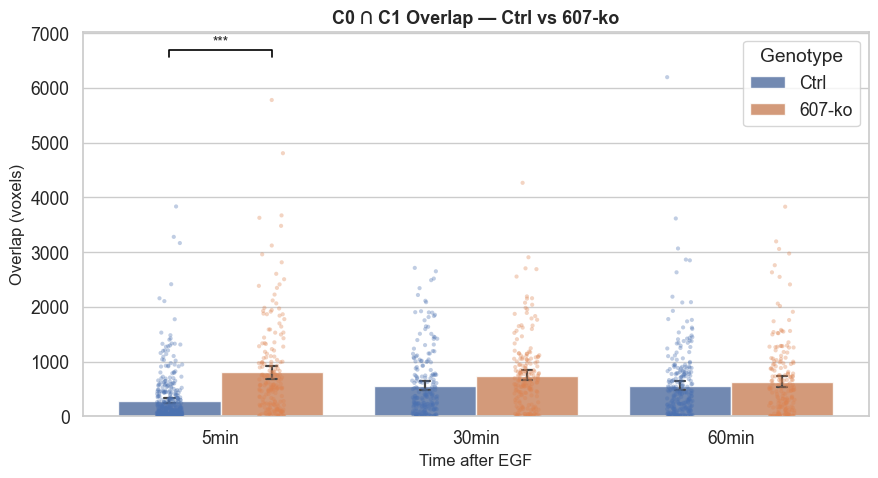

Saved → figures/overlap_c0_c1.png


In [7]:
plot_metric(cells, METRIC,
            ylabel='Overlap (voxels)',
            title='C0 ∩ C1 Overlap — Ctrl vs 607-ko',
            fname='overlap_c0_c1.png',
            bonf_df=bonf)

### 4b · C0 ∩ C2 overlap

In [8]:
METRIC = 'c0_c2_overlap_voxels'

aov = run_two_way_anova(cells, METRIC)
print('=== Two-way ANOVA: C0 ∩ C2 overlap ===')
show_anova(aov)

=== Two-way ANOVA: C0 ∩ C2 overlap ===


,Source,SS,DF,MS,F,p_unc,np2
0,genotype,1.356850e+05,1.0,135684.9895,86.1371,0.0000,0.0551
1,timepoint,9.305408e+03,2.0,4652.7043,2.9537,0.0525,0.0040
2,genotype * timepoint,1.738668e+03,2.0,869.3339,0.5519,0.5760,0.0007
3,Residual,2.328176e+06,1478.0,1575.2207,NaN,NaN,NaN


In [9]:
bonf = run_bonferroni(cells, METRIC)
print('=== Bonferroni post-hoc: C0 ∩ C2 overlap ===')
display(bonf.round(4))

=== Bonferroni post-hoc: C0 ∩ C2 overlap ===


,A,B,mean(A),mean(B),T,dof,p_unc,p_corr,BF10
0,607-ko 30min,Ctrl 5min,39.68,15.59,6.6198,258.5729,0.0000,0.0000,9.428e+07
1,607-ko 30min,Ctrl 60min,39.68,15.66,6.5259,266.6625,0.0000,0.0000,4.394e+07
2,607-ko 5min,Ctrl 5min,37.70,15.59,5.3150,252.6870,0.0000,0.0000,6.958e+04
3,607-ko 5min,Ctrl 60min,37.70,15.66,5.2523,259.4938,0.0000,0.0000,4.839e+04
4,607-ko 60min,Ctrl 5min,35.21,15.59,4.7093,248.7479,0.0000,0.0001,4005.301
5,607-ko 60min,Ctrl 60min,35.21,15.66,4.6521,255.4695,0.0000,0.0001,3072.754
6,607-ko 30min,Ctrl 30min,39.68,23.04,4.1957,325.3647,0.0000,0.0005,468.646
7,607-ko 5min,Ctrl 30min,37.70,23.04,3.2949,309.0890,0.0011,0.0165,19.554
8,Ctrl 30min,Ctrl 5min,23.04,15.59,2.9393,409.2024,0.0035,0.0521,6.148
9,Ctrl 30min,Ctrl 60min,23.04,15.66,2.8454,407.4358,0.0047,0.0699,5.042


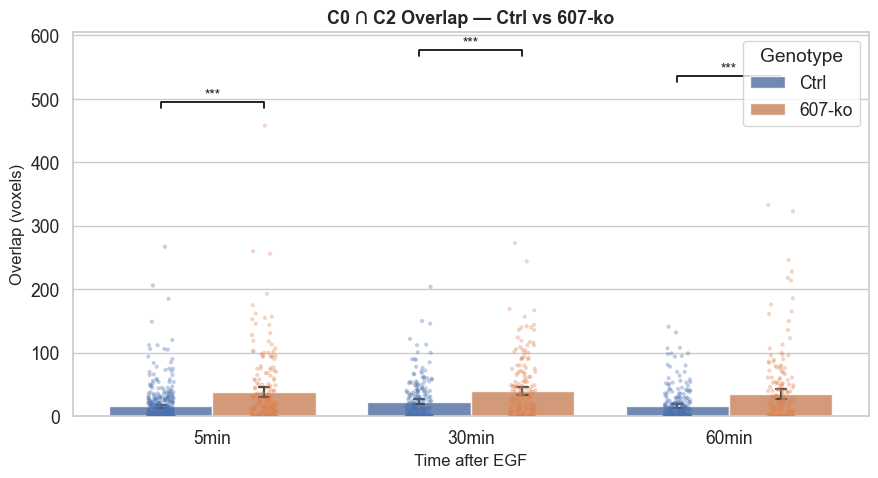

Saved → figures/overlap_c0_c2.png


In [10]:
plot_metric(cells, METRIC,
            ylabel='Overlap (voxels)',
            title='C0 ∩ C2 Overlap — Ctrl vs 607-ko',
            fname='overlap_c0_c2.png',
            bonf_df=bonf)

In [11]:
METRIC = 'c0_c1_overlap_voxels'

aov = run_two_way_anova(cells, METRIC)
print('=== Two-way ANOVA: C0 ∩ C1 overlap ===')
show_anova(aov)

=== Two-way ANOVA: C0 ∩ C1 overlap ===


,Source,SS,DF,MS,F,p_unc,np2
0,genotype,2.728078e+07,1.0,2.728078e+07,65.5803,0.0000,0.0425
1,timepoint,6.402699e+06,2.0,3.201350e+06,7.6957,0.0005,0.0103
2,genotype * timepoint,1.349047e+07,2.0,6.745235e+06,16.2149,0.0000,0.0215
3,Residual,6.148336e+08,1478.0,4.159902e+05,NaN,NaN,NaN


### 4c · C1 ∩ C2 overlap

In [12]:
METRIC = 'c1_c2_overlap_voxels'

aov = run_two_way_anova(cells, METRIC)
print('=== Two-way ANOVA: C1 ∩ C2 overlap ===')
show_anova(aov)

=== Two-way ANOVA: C1 ∩ C2 overlap ===


,Source,SS,DF,MS,F,p_unc,np2
0,genotype,4.771981e+06,1.0,4.771981e+06,80.0764,0.0,0.0514
1,timepoint,2.872043e+07,2.0,1.436022e+07,240.9722,0.0,0.2459
2,genotype * timepoint,1.917207e+06,2.0,9.586036e+05,16.0859,0.0,0.0213
3,Residual,8.807819e+07,1478.0,5.959282e+04,NaN,NaN,NaN


In [13]:
bonf = run_bonferroni(cells, METRIC)
print('=== Bonferroni post-hoc: C1 ∩ C2 overlap ===')
display(bonf.round(4))

=== Bonferroni post-hoc: C1 ∩ C2 overlap ===


,A,B,mean(A),mean(B),T,dof,p_unc,p_corr,BF10
0,Ctrl 5min,Ctrl 60min,20.28,293.16,-15.3361,267.9588,0.0000,0.0000,1.707e+42
1,607-ko 30min,Ctrl 5min,448.94,20.28,16.2584,191.9548,0.0000,0.0000,9.09e+45
2,607-ko 30min,607-ko 5min,448.94,65.72,14.2283,208.5607,0.0000,0.0000,7.086e+33
3,Ctrl 30min,Ctrl 5min,223.12,20.28,13.8265,224.3124,0.0000,0.0000,5.226e+34
4,607-ko 60min,Ctrl 5min,397.02,20.28,13.6830,198.8574,0.0000,0.0000,8.334e+33
5,607-ko 5min,Ctrl 60min,65.72,293.16,-12.2117,316.8162,0.0000,0.0000,3.931e+26
6,607-ko 5min,607-ko 60min,65.72,397.02,-11.7993,214.6282,0.0000,0.0000,2.88e+24
7,607-ko 5min,Ctrl 30min,65.72,223.12,-10.0458,284.0066,0.0000,0.0000,1.79e+18
8,607-ko 30min,Ctrl 30min,448.94,223.12,7.5137,299.5358,0.0000,0.0000,1.726e+10
9,607-ko 5min,Ctrl 5min,65.72,20.28,7.4343,242.9326,0.0000,0.0000,1.734e+10


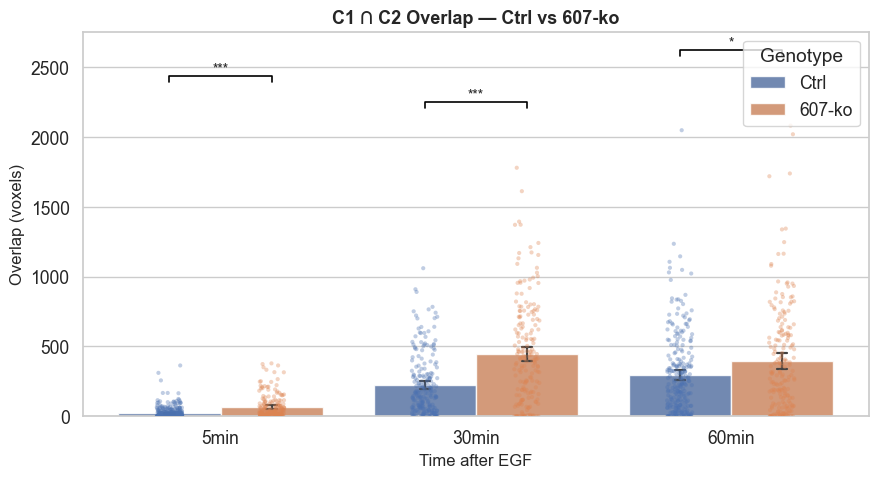

Saved → figures/overlap_c1_c2.png


In [14]:
plot_metric(cells, METRIC,
            ylabel='Overlap (voxels)',
            title='C1 ∩ C2 Overlap — Ctrl vs 607-ko',
            fname='overlap_c1_c2.png',
            bonf_df=bonf)

## 5 · Distance to nucleus
Per-cell mean distance of blobs in each channel to the nucleus centroid (µm).

### 5a · C0 — distance to nucleus

In [15]:
METRIC = 'c0_dist_to_nucleus_um_mean'

aov = run_two_way_anova(cells, METRIC)
print('=== Two-way ANOVA: C0 dist to nucleus ===')
show_anova(aov)

=== Two-way ANOVA: C0 dist to nucleus ===


,Source,SS,DF,MS,F,p_unc,np2
0,genotype,208.5192,1.0,208.5192,29.8952,0.0000,0.0199
1,timepoint,46.9820,2.0,23.4910,3.3679,0.0347,0.0046
2,genotype * timepoint,87.9113,2.0,43.9556,6.3019,0.0019,0.0085
3,Residual,10253.2639,1470.0,6.9750,NaN,NaN,NaN


In [16]:
bonf = run_bonferroni(cells, METRIC)
print('=== Bonferroni post-hoc: C0 dist to nucleus ===')
display(bonf.round(4))

=== Bonferroni post-hoc: C0 dist to nucleus ===


,A,B,mean(A),mean(B),T,dof,p_unc,p_corr,BF10
0,607-ko 30min,Ctrl 30min,7.03,8.55,-6.1652,398.0073,0.0000,0.0000,5.234e+06
1,607-ko 60min,Ctrl 30min,7.06,8.55,-6.0708,399.5878,0.0000,0.0000,3.148e+06
2,607-ko 5min,Ctrl 30min,7.38,8.55,-4.7290,405.7508,0.0000,0.0000,4271.6
3,Ctrl 30min,Ctrl 60min,8.55,7.71,3.4712,428.8208,0.0006,0.0086,33.276
4,Ctrl 30min,Ctrl 5min,8.55,7.69,3.4528,490.4703,0.0006,0.0090,29.886
5,607-ko 30min,Ctrl 60min,7.03,7.71,-3.1303,434.3946,0.0019,0.0280,11.661
6,607-ko 60min,Ctrl 60min,7.06,7.71,-2.9989,445.6669,0.0029,0.0429,7.898
7,607-ko 30min,Ctrl 5min,7.03,7.69,-2.9877,524.8029,0.0029,0.0441,7.304
8,607-ko 60min,Ctrl 5min,7.06,7.69,-2.8575,542.8136,0.0044,0.0665,5.026
9,607-ko 5min,607-ko 60min,7.38,7.06,1.4418,395.8649,0.1501,1.0000,0.302


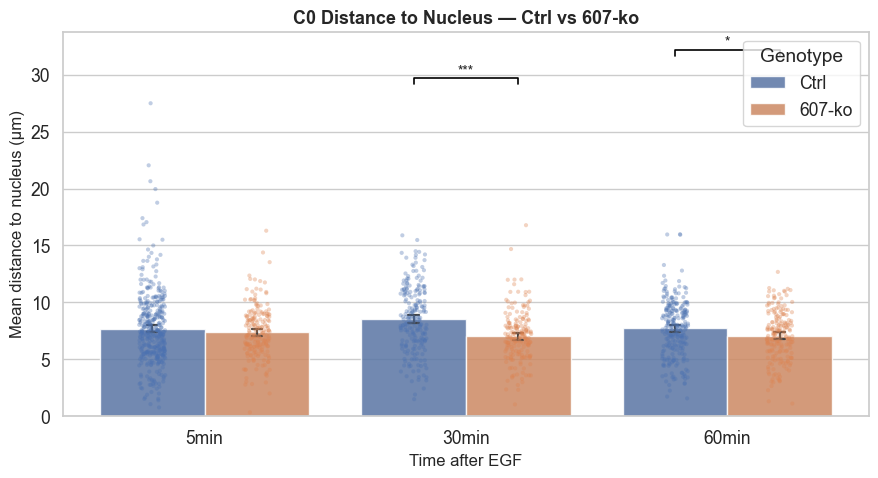

Saved → figures/dist_nucleus_c0.png


In [17]:
plot_metric(cells, METRIC,
            ylabel='Mean distance to nucleus (µm)',
            title='C0 Distance to Nucleus — Ctrl vs 607-ko',
            fname='dist_nucleus_c0.png',
            bonf_df=bonf)

### 5b · C1 — distance to nucleus

In [18]:
METRIC = 'c1_dist_to_nucleus_um_mean'

aov = run_two_way_anova(cells, METRIC)
print('=== Two-way ANOVA: C1 dist to nucleus ===')
show_anova(aov)

=== Two-way ANOVA: C1 dist to nucleus ===


,Source,SS,DF,MS,F,p_unc,np2
0,genotype,132.4080,1.0,132.4080,20.5275,0.0000,0.0138
1,timepoint,71.9190,2.0,35.9595,5.5749,0.0039,0.0075
2,genotype * timepoint,22.0014,2.0,11.0007,1.7055,0.1820,0.0023
3,Residual,9481.9142,1470.0,6.4503,NaN,NaN,NaN


In [19]:
bonf = run_bonferroni(cells, METRIC)
print('=== Bonferroni post-hoc: C1 dist to nucleus ===')
display(bonf.round(4))

=== Bonferroni post-hoc: C1 dist to nucleus ===


,A,B,mean(A),mean(B),T,dof,p_unc,p_corr,BF10
0,607-ko 60min,Ctrl 30min,6.74,7.74,-4.8358,406.1245,0.0000,0.0000,6844.554
1,607-ko 30min,Ctrl 30min,6.73,7.74,-4.7863,404.7987,0.0000,0.0000,5491.238
2,607-ko 60min,Ctrl 5min,6.74,7.73,-4.5858,592.2685,0.0000,0.0001,2329.771
3,607-ko 30min,Ctrl 5min,6.73,7.73,-4.5442,579.3965,0.0000,0.0001,1952.988
4,Ctrl 30min,Ctrl 60min,7.74,7.17,2.7604,447.5809,0.0060,0.0901,4.014
5,Ctrl 5min,Ctrl 60min,7.73,7.17,2.5927,667.7668,0.0097,0.1460,2.327
6,607-ko 5min,607-ko 60min,7.25,6.74,2.5266,389.1957,0.0119,0.1787,2.376
7,607-ko 30min,607-ko 5min,6.73,7.25,-2.5092,387.8070,0.0125,0.1876,2.29
8,607-ko 60min,Ctrl 60min,6.74,7.17,-2.2737,447.6679,0.0235,0.3519,1.268
9,607-ko 30min,Ctrl 60min,6.73,7.17,-2.2565,435.8672,0.0245,0.3680,1.229


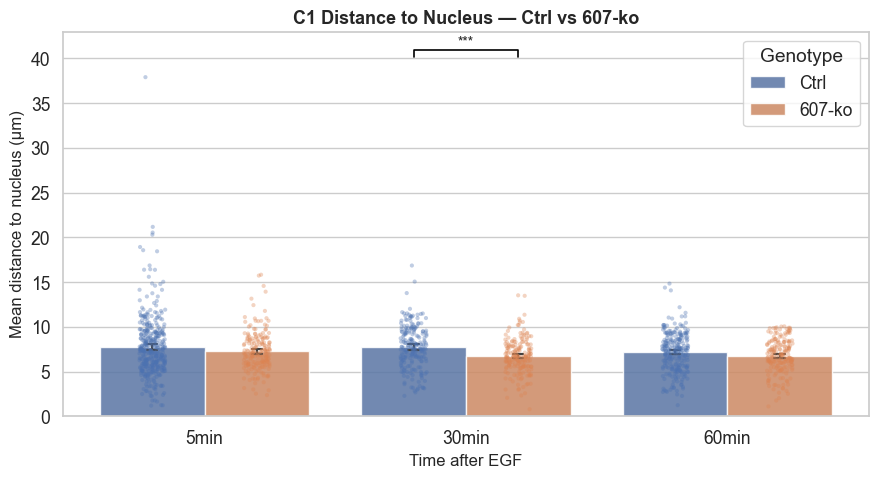

Saved → figures/dist_nucleus_c1.png


In [20]:
plot_metric(cells, METRIC,
            ylabel='Mean distance to nucleus (µm)',
            title='C1 Distance to Nucleus — Ctrl vs 607-ko',
            fname='dist_nucleus_c1.png',
            bonf_df=bonf)

### 5c · C2 — distance to nucleus

In [21]:
METRIC = 'c2_dist_to_nucleus_um_mean'

aov = run_two_way_anova(cells, METRIC)
print('=== Two-way ANOVA: C2 dist to nucleus ===')
show_anova(aov)

=== Two-way ANOVA: C2 dist to nucleus ===


,Source,SS,DF,MS,F,p_unc,np2
0,genotype,61.5047,1.0,61.5047,10.5821,0.0012,0.0072
1,timepoint,64.0721,2.0,32.0360,5.5119,0.0041,0.0075
2,genotype * timepoint,38.0619,2.0,19.0309,3.2743,0.0381,0.0045
3,Residual,8497.3650,1462.0,5.8122,NaN,NaN,NaN


In [22]:
bonf = run_bonferroni(cells, METRIC)
print('=== Bonferroni post-hoc: C2 dist to nucleus ===')
display(bonf.round(4))

=== Bonferroni post-hoc: C2 dist to nucleus ===


,A,B,mean(A),mean(B),T,dof,p_unc,p_corr,BF10
0,607-ko 5min,Ctrl 30min,6.91,7.91,-4.2821,414.6457,0.0000,0.0003,657.992
1,607-ko 60min,Ctrl 30min,6.96,7.91,-4.0706,411.6824,0.0001,0.0008,288.593
2,607-ko 30min,Ctrl 30min,6.98,7.91,-4.0145,403.9538,0.0001,0.0011,234.155
3,Ctrl 30min,Ctrl 5min,7.91,7.09,3.8178,459.6068,0.0002,0.0023,106.499
4,Ctrl 30min,Ctrl 60min,7.91,7.21,3.1245,448.8485,0.0019,0.0284,11.189
5,607-ko 30min,Ctrl 5min,6.98,7.09,-0.5427,437.7672,0.5876,1.0000,0.113
6,607-ko 30min,607-ko 60min,6.98,6.96,0.0660,381.8879,0.9474,1.0000,0.113
7,607-ko 30min,607-ko 5min,6.98,6.91,0.2989,384.8671,0.7652,1.0000,0.117
8,607-ko 5min,Ctrl 5min,6.91,7.09,-0.8644,454.6290,0.3878,1.0000,0.139
9,607-ko 5min,607-ko 60min,6.91,6.96,-0.2327,392.9992,0.8161,1.0000,0.114


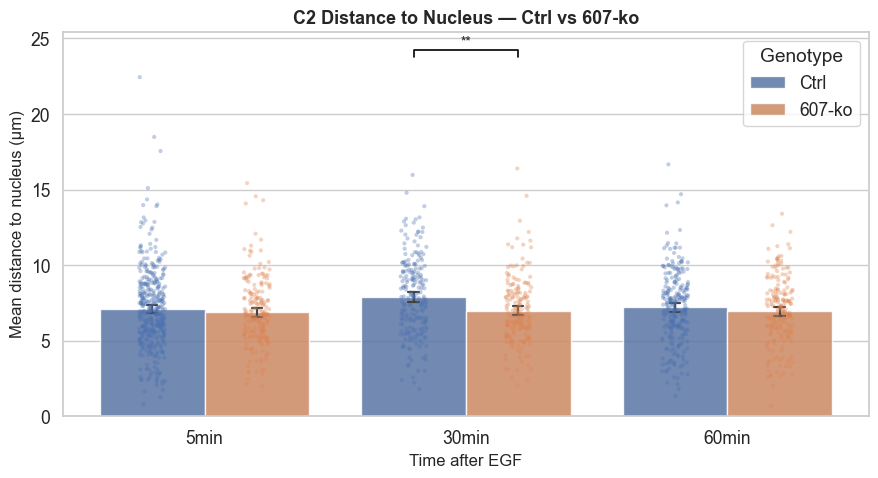

Saved → figures/dist_nucleus_c2.png


In [23]:
plot_metric(cells, METRIC,
            ylabel='Mean distance to nucleus (µm)',
            title='C2 Distance to Nucleus — Ctrl vs 607-ko',
            fname='dist_nucleus_c2.png',
            bonf_df=bonf)

## 6 · Distance to membrane (cell surface)
Per-cell mean distance of blobs in each channel to the cell surface (µm).

### 6a · C0 — distance to membrane

In [24]:
METRIC = 'c0_dist_to_surface_um_mean'

aov = run_two_way_anova(cells, METRIC)
print('=== Two-way ANOVA: C0 dist to membrane ===')
show_anova(aov)

=== Two-way ANOVA: C0 dist to membrane ===


,Source,SS,DF,MS,F,p_unc,np2
0,genotype,25.3410,1.0,25.3410,80.9107,0.0000,0.0522
1,timepoint,5.3390,2.0,2.6695,8.5233,0.0002,0.0115
2,genotype * timepoint,0.7891,2.0,0.3945,1.2597,0.2840,0.0017
3,Residual,460.3999,1470.0,0.3132,NaN,NaN,NaN


In [25]:
bonf = run_bonferroni(cells, METRIC)
print('=== Bonferroni post-hoc: C0 dist to membrane ===')
display(bonf.round(4))

=== Bonferroni post-hoc: C0 dist to membrane ===


,A,B,mean(A),mean(B),T,dof,p_unc,p_corr,BF10
0,607-ko 5min,Ctrl 60min,2.02,1.58,8.3567,427.4832,0.0000,0.0000,6.78e+12
1,607-ko 30min,Ctrl 60min,1.94,1.58,6.5959,397.2656,0.0000,0.0000,6.615e+07
2,607-ko 5min,Ctrl 5min,2.02,1.74,5.8434,380.6107,0.0000,0.0000,1.087e+06
3,607-ko 60min,Ctrl 60min,1.90,1.58,5.6716,391.4012,0.0000,0.0000,3.956e+05
4,607-ko 5min,Ctrl 30min,2.02,1.74,5.2977,404.5767,0.0000,0.0000,5.886e+04
5,607-ko 30min,Ctrl 5min,1.94,1.74,3.9989,343.8207,0.0001,0.0012,214.294
6,Ctrl 5min,Ctrl 60min,1.74,1.58,3.6819,541.5981,0.0003,0.0038,63.005
7,607-ko 30min,Ctrl 30min,1.94,1.74,3.6591,381.2344,0.0003,0.0043,65.087
8,Ctrl 30min,Ctrl 60min,1.74,1.58,3.2424,471.2032,0.0013,0.0190,16.018
9,607-ko 60min,Ctrl 5min,1.90,1.74,3.0865,336.5229,0.0022,0.0329,9.671


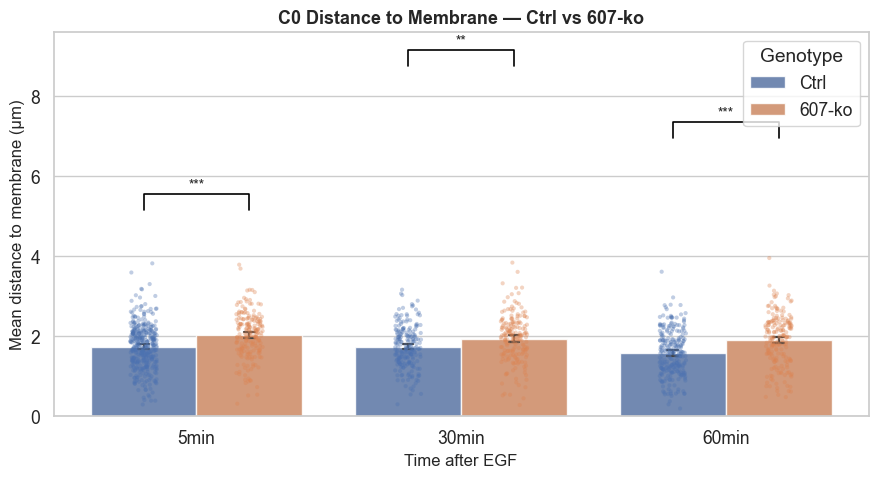

Saved → figures/dist_membrane_c0.png


In [26]:
plot_metric(cells, METRIC,
            ylabel='Mean distance to membrane (µm)',
            title='C0 Distance to Membrane — Ctrl vs 607-ko',
            fname='dist_membrane_c0.png',
            bonf_df=bonf)

### 6b · C1 — distance to membrane

In [27]:
METRIC = 'c1_dist_to_surface_um_mean'

aov = run_two_way_anova(cells, METRIC)
print('=== Two-way ANOVA: C1 dist to membrane ===')
show_anova(aov)

=== Two-way ANOVA: C1 dist to membrane ===


,Source,SS,DF,MS,F,p_unc,np2
0,genotype,19.5964,1.0,19.5964,51.7776,0.0000,0.0340
1,timepoint,27.5420,2.0,13.7710,36.3858,0.0000,0.0472
2,genotype * timepoint,5.7967,2.0,2.8983,7.6580,0.0005,0.0103
3,Residual,556.3537,1470.0,0.3785,NaN,NaN,NaN


In [28]:
bonf = run_bonferroni(cells, METRIC)
print('=== Bonferroni post-hoc: C1 dist to membrane ===')
display(bonf.round(4))

=== Bonferroni post-hoc: C1 dist to membrane ===


,A,B,mean(A),mean(B),T,dof,p_unc,p_corr,BF10
0,607-ko 30min,Ctrl 5min,2.07,1.56,9.7345,345.4687,0.0000,0.0000,5.455e+17
1,Ctrl 30min,Ctrl 5min,2.02,1.56,8.5052,377.2887,0.0000,0.0000,3.624e+13
2,607-ko 60min,Ctrl 5min,2.05,1.56,8.4269,315.1080,0.0000,0.0000,1.896e+13
3,607-ko 5min,Ctrl 5min,1.93,1.56,7.6788,408.4666,0.0000,0.0000,9.046e+10
4,Ctrl 5min,Ctrl 60min,1.56,1.80,-5.0705,526.7801,0.0000,0.0000,2.068e+04
5,607-ko 30min,Ctrl 60min,2.07,1.80,4.6809,408.8468,0.0000,0.0001,3487.242
6,607-ko 60min,Ctrl 60min,2.05,1.80,3.9908,380.3587,0.0001,0.0012,211.272
7,Ctrl 30min,Ctrl 60min,2.02,1.80,3.7201,439.8713,0.0002,0.0034,77.742
8,607-ko 30min,607-ko 5min,2.07,1.93,2.4427,380.1147,0.0150,0.2255,1.957
9,607-ko 5min,Ctrl 60min,1.93,1.80,2.3818,450.1687,0.0176,0.2646,1.605


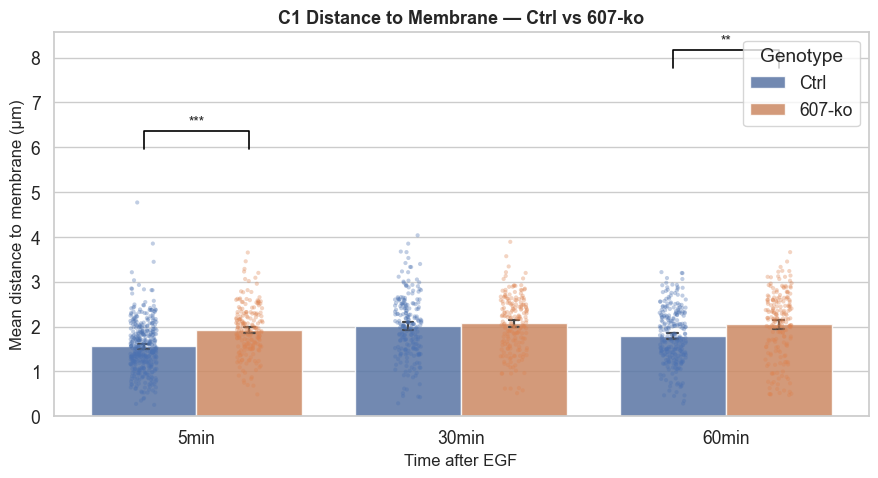

Saved → figures/dist_membrane_c1.png


In [29]:
plot_metric(cells, METRIC,
            ylabel='Mean distance to membrane (µm)',
            title='C1 Distance to Membrane — Ctrl vs 607-ko',
            fname='dist_membrane_c1.png',
            bonf_df=bonf)

### 6c · C2 — distance to membrane

In [30]:
METRIC = 'c2_dist_to_surface_um_mean'

aov = run_two_way_anova(cells, METRIC)
print('=== Two-way ANOVA: C2 dist to membrane ===')
show_anova(aov)

=== Two-way ANOVA: C2 dist to membrane ===


,Source,SS,DF,MS,F,p_unc,np2
0,genotype,13.2031,1.0,13.2031,24.9330,0.0000,0.0168
1,timepoint,16.5862,2.0,8.2931,15.6609,0.0000,0.0210
2,genotype * timepoint,5.4177,2.0,2.7088,5.1154,0.0061,0.0069
3,Residual,774.1932,1462.0,0.5295,NaN,NaN,NaN


In [31]:
bonf = run_bonferroni(cells, METRIC)
print('=== Bonferroni post-hoc: C2 dist to membrane ===')
display(bonf.round(4))

=== Bonferroni post-hoc: C2 dist to membrane ===


,A,B,mean(A),mean(B),T,dof,p_unc,p_corr,BF10
0,607-ko 5min,Ctrl 60min,2.30,1.77,7.9289,395.0992,0.0000,0.0000,3.365e+11
1,607-ko 30min,607-ko 5min,1.98,2.30,-4.5883,376.6992,0.0000,0.0001,2323.138
2,607-ko 5min,Ctrl 30min,2.30,1.98,4.5200,404.6630,0.0000,0.0001,1743.883
3,607-ko 5min,Ctrl 5min,2.30,2.00,4.5001,414.6768,0.0000,0.0001,1608.249
4,Ctrl 5min,Ctrl 60min,2.00,1.77,4.1079,625.4480,0.0000,0.0007,309.52
5,607-ko 5min,607-ko 60min,2.30,2.01,3.9103,392.9634,0.0001,0.0016,159.524
6,607-ko 60min,Ctrl 60min,2.01,1.77,3.6141,394.7761,0.0003,0.0051,54.636
7,607-ko 30min,Ctrl 60min,1.98,1.77,3.5319,420.2577,0.0005,0.0069,41.63
8,Ctrl 30min,Ctrl 60min,1.98,1.77,3.3423,450.9693,0.0009,0.0135,21.9
9,607-ko 30min,Ctrl 30min,1.98,1.98,0.0618,403.9603,0.9507,1.0000,0.11


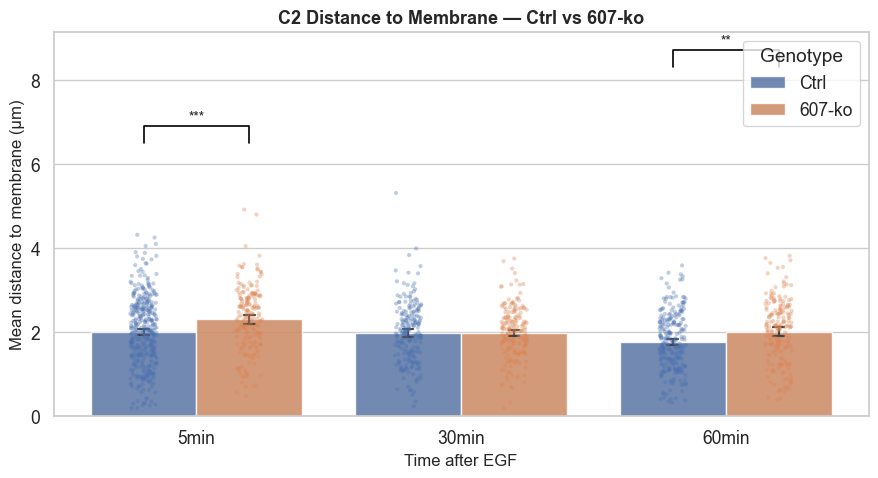

Saved → figures/dist_membrane_c2.png


In [32]:
plot_metric(cells, METRIC,
            ylabel='Mean distance to membrane (µm)',
            title='C2 Distance to Membrane — Ctrl vs 607-ko',
            fname='dist_membrane_c2.png',
            bonf_df=bonf)

## 7 · Summary ANOVA table (all metrics)

In [33]:
METRICS = {
    'C0∩C1 overlap (vox)'    : 'c0_c1_overlap_voxels',
    'C0∩C2 overlap (vox)'    : 'c0_c2_overlap_voxels',
    'C1∩C2 overlap (vox)'    : 'c1_c2_overlap_voxels',
    'C0 dist nucleus (µm)'   : 'c0_dist_to_nucleus_um_mean',
    'C1 dist nucleus (µm)'   : 'c1_dist_to_nucleus_um_mean',
    'C2 dist nucleus (µm)'   : 'c2_dist_to_nucleus_um_mean',
    'C0 dist membrane (µm)'  : 'c0_dist_to_surface_um_mean',
    'C1 dist membrane (µm)'  : 'c1_dist_to_surface_um_mean',
    'C2 dist membrane (µm)'  : 'c2_dist_to_surface_um_mean',
}

rows = []
for label, col in METRICS.items():
    aov = run_two_way_anova(cells, col)
    for _, r in aov.iterrows():
        if r['Source'] == 'Residual':
            continue
        rows.append({
            'Metric'  : label,
            'Factor'  : r['Source'],
            'F'       : round(r['F'], 3),
            'p'       : round(r['p_unc'], 4),
            'η²p'     : round(r.get('np2', float('nan')), 4),
            'sig'     : sig_label(r['p_unc'])
        })

anova_summary = pd.DataFrame(rows)
print('=== Two-way ANOVA summary for all metrics ===')
display(anova_summary)

out = FIG_DIR / 'anova_summary.csv'
anova_summary.to_csv(out, index=False)
print(f'Saved → {out}')

=== Two-way ANOVA summary for all metrics ===


,Metric,Factor,F,p,η²p,sig
0,C0∩C1 overlap (vox),genotype,65.580,0.0000,0.0425,***
1,C0∩C1 overlap (vox),timepoint,7.696,0.0005,0.0103,***
2,C0∩C1 overlap (vox),genotype * timepoint,16.215,0.0000,0.0215,***
3,C0∩C2 overlap (vox),genotype,86.137,0.0000,0.0551,***
4,C0∩C2 overlap (vox),timepoint,2.954,0.0525,0.0040,ns
5,C0∩C2 overlap (vox),genotype * timepoint,0.552,0.5760,0.0007,ns
6,C1∩C2 overlap (vox),genotype,80.076,0.0000,0.0514,***
7,C1∩C2 overlap (vox),timepoint,240.972,0.0000,0.2459,***
8,C1∩C2 overlap (vox),genotype * timepoint,16.086,0.0000,0.0213,***
9,C0 dist nucleus (µm),genotype,29.895,0.0000,0.0199,***


Saved → C:\Users\NIC-ADMIN4\Workspace\Jupyter\jupyter_napari\Marta\figures\anova_summary.csv


## 8 · Export all Bonferroni tables

In [34]:
all_bonf = []
for label, col in METRICS.items():
    bonf = run_bonferroni(cells, col)
    bonf.insert(0, 'Metric', label)
    all_bonf.append(bonf)

bonf_all = pd.concat(all_bonf, ignore_index=True)
bonf_all['sig'] = bonf_all['p_corr'].apply(sig_label)

out = FIG_DIR / 'bonferroni_all_metrics.csv'
bonf_all.to_csv(out, index=False)
print(f'Saved → {out}')

# Show only significant pairs
sig_only = bonf_all[bonf_all['p_corr'] < 0.05]
print(f'\n{len(sig_only)} significant pairwise comparisons (p_corr < 0.05):')
display(sig_only.round(4))

Saved → C:\Users\NIC-ADMIN4\Workspace\Jupyter\jupyter_napari\Marta\figures\bonferroni_all_metrics.csv

74 significant pairwise comparisons (p_corr < 0.05):


,Metric,A,B,mean(A),mean(B),T,dof,p_unc,p_corr,BF10,sig
0,C0∩C1 overlap (vox),607-ko 30min,Ctrl 5min,743.23,280.84,8.7728,278.2950,0.0000,0.0000,2.587e+14,***
1,C0∩C1 overlap (vox),607-ko 5min,Ctrl 5min,801.54,280.84,7.8994,254.3945,0.0000,0.0000,4.265e+11,***
2,C0∩C1 overlap (vox),607-ko 60min,Ctrl 5min,629.52,280.84,6.5325,285.5178,0.0000,0.0000,5.597e+07,***
3,C0∩C1 overlap (vox),Ctrl 30min,Ctrl 5min,558.53,280.84,5.9583,352.6704,0.0000,0.0000,2.052e+06,***
4,C0∩C1 overlap (vox),Ctrl 5min,Ctrl 60min,280.84,554.20,-5.7311,412.8823,0.0000,0.0000,5.961e+05,***
...,...,...,...,...,...,...,...,...,...,...,...
124,C2 dist membrane (µm),Ctrl 5min,Ctrl 60min,2.00,1.77,4.1079,625.4480,0.0000,0.0007,309.52,***
125,C2 dist membrane (µm),607-ko 5min,607-ko 60min,2.30,2.01,3.9103,392.9634,0.0001,0.0016,159.524,**
126,C2 dist membrane (µm),607-ko 60min,Ctrl 60min,2.01,1.77,3.6141,394.7761,0.0003,0.0051,54.636,**
127,C2 dist membrane (µm),607-ko 30min,Ctrl 60min,1.98,1.77,3.5319,420.2577,0.0005,0.0069,41.63,**


---
## 9 · Overlap change over time — within each genotype
**Question:** Does each overlap metric change significantly across the three time points?  
**Design:** One-way ANOVA (factor = timepoint: 5 min · 30 min · 60 min) run **separately** for H23 Ctrl and H23 607-ko.  
**Post-hoc:** Bonferroni-corrected pairwise t-tests between 5 min vs 30 min, 5 min vs 60 min, and 30 min vs 60 min.  
> ⚠️ Note: the available time points in this dataset are **5 min, 30 min and 60 min**.

In [35]:
def run_oneway_anova_timepoint(df, metric_col, genotype):
    """One-way ANOVA across timepoints for a single genotype."""
    sub = df[df['genotype'] == genotype][['timepoint', metric_col]].dropna().copy()
    sub['timepoint'] = sub['timepoint'].astype(str)
    aov = pg.anova(data=sub, dv=metric_col, between='timepoint', detailed=True)
    aov.insert(0, 'Genotype', genotype)
    return aov


def run_bonferroni_6groups(df, metric_col):
    """
    Full Bonferroni pairwise test across all 6 groups (2 genotypes × 3 timepoints).
    Attaches group means and classifies each pair.
    """
    sub = df[['genotype', 'timepoint', metric_col]].dropna().copy()
    sub['group'] = sub['genotype'] + ' ' + sub['timepoint'].astype(str)
    gm = sub.groupby('group')[metric_col].mean()

    ph = pg.pairwise_tests(data=sub, dv=metric_col, between='group',
                           parametric=True, padjust='bonf')
    ph['mean(A)'] = ph['A'].map(gm).round(1)
    ph['mean(B)'] = ph['B'].map(gm).round(1)
    ph['Δ mean']  = (ph['mean(A)'] - ph['mean(B)']).round(1)

    keep = ['A', 'B', 'mean(A)', 'mean(B)', 'Δ mean', 'T', 'dof', 'p_unc', 'p_corr']
    keep = [c for c in keep if c in ph.columns]
    ph = ph[keep].copy()
    ph['sig'] = ph['p_corr'].apply(sig_label)

    def pair_type(row):
        ma = re.match(r'(Ctrl|607-ko) (\d+min)', str(row['A']))
        mb = re.match(r'(Ctrl|607-ko) (\d+min)', str(row['B']))
        if not ma or not mb:
            return 'other'
        ga, ta = ma.groups()
        gb, tb = mb.groups()
        if ga == gb:   return 'within-genotype'
        if ta == tb:   return 'same-timepoint'
        return 'cross'

    ph['pair_type'] = ph.apply(pair_type, axis=1)

    tp_rank = {'5min': 0, '30min': 1, '60min': 2}
    def sort_key(row):
        ma = re.match(r'(Ctrl|607-ko) (\d+min)', str(row['A']))
        mb = re.match(r'(Ctrl|607-ko) (\d+min)', str(row['B']))
        if ma and mb:
            return (0 if row['pair_type'] == 'same-timepoint' else 1,
                    tp_rank.get(ma.group(2), 9), tp_rank.get(mb.group(2), 9))
        return (2, 9, 9)
    ph = ph.iloc[sorted(range(len(ph)), key=lambda i: sort_key(ph.iloc[i]))].reset_index(drop=True)
    return ph


def overlap_timecourse_table(df, metric_col, label):
    """
    Prints two-way ANOVA + one-way ANOVA per genotype + full Bonferroni table.
    Returns the Bonferroni result as bonf_c0X for use in the plot cell.
    """
    print(f'\n{"="*65}')
    print(f'  {label}')
    print(f'{"="*65}')

    # Two-way ANOVA
    print('\n  Two-way ANOVA (genotype × timepoint):')
    aov2 = run_two_way_anova(df, metric_col)
    show_anova(aov2)

    # One-way per genotype
    print()
    for geno in ['Ctrl', '607-ko']:
        aov1    = run_oneway_anova_timepoint(df, metric_col, geno)
        aov_row = aov1[aov1['Source'] == 'timepoint'].iloc[0]
        err_row = aov1[aov1['Source'] == 'Within'].iloc[0]
        print(f'  [{geno}]  F({int(aov_row["DF"])}, {int(err_row["DF"])}) = '
              f'{aov_row["F"]:.3f},  p = {aov_row["p_unc"]:.4f}  {sig_label(aov_row["p_unc"])}')

    # Full Bonferroni (all 15 pairs)
    bonf = run_bonferroni_6groups(df, metric_col)
    print('\n  Bonferroni pairwise — all 6 groups:')
    display(bonf.round(4))

    # Save CSV
    out = FIG_DIR / f'timecourse_{metric_col}.csv'
    bonf.to_csv(out, index=False)
    print(f'  Saved → {out.name}')
    return bonf


def plot_overlap_combined(df, metric_col, ylabel, title, fname, bonf_df):
    """
    Single grouped bar chart (mean ± 95% CI): x=timepoint, hue=genotype.
    Individual data points overlaid.
    Bonferroni brackets for same-timepoint and within-genotype pairs.
    """
    sub = df[['genotype', 'timepoint', metric_col]].dropna().copy()
    sub['timepoint'] = sub['timepoint'].astype(str)

    fig, ax = plt.subplots(figsize=(10, 6))

    try:
        sns.barplot(data=sub, x='timepoint', y=metric_col, hue='genotype',
                    order=TIME_ORDER, hue_order=['Ctrl', '607-ko'],
                    palette=COND_PALETTE, errorbar=('ci', 95),
                    capsize=0.08, errwidth=1.6, alpha=0.85, ax=ax)
    except TypeError:
        sns.barplot(data=sub, x='timepoint', y=metric_col, hue='genotype',
                    order=TIME_ORDER, hue_order=['Ctrl', '607-ko'],
                    palette=COND_PALETTE, ci=95,
                    capsize=0.08, errwidth=1.6, alpha=0.85, ax=ax)

    sns.stripplot(data=sub, x='timepoint', y=metric_col, hue='genotype',
                  order=TIME_ORDER, hue_order=['Ctrl', '607-ko'],
                  palette=COND_PALETTE, dodge=True, size=3,
                  alpha=0.35, jitter=True, ax=ax)

    ax.set_xlabel('Time after EGF', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Genotype', loc='upper right')

    tp_idx   = {tp: i for i, tp in enumerate(TIME_ORDER)}
    geno_off = {'Ctrl': -0.2, '607-ko': 0.2}
    sig      = bonf_df[bonf_df['p_corr'] < 0.05].copy()
    y_top    = sub[metric_col].max()
    unit     = max(y_top * 0.04, 1.0)

    def get_x(group_str):
        m = re.match(r'(Ctrl|607-ko) (\d+min)', str(group_str))
        if m and m.group(2) in tp_idx:
            return tp_idx[m.group(2)] + geno_off[m.group(1)]
        return None

    def draw_bracket(x1, x2, y_base, label):
        h = unit * 0.4
        ax.plot([x1, x1, x2, x2], [y_base, y_base+h, y_base+h, y_base],
                lw=1.3, color='black')
        ax.text((x1+x2)/2, y_base+h+unit*0.05,
                label, ha='center', va='bottom', fontsize=10)

    same_tp  = sig[sig['pair_type'] == 'same-timepoint']
    level0_y = y_top + unit * 1.2
    for _, row in same_tp.iterrows():
        x1, x2 = get_x(row['A']), get_x(row['B'])
        if x1 is None or x2 is None: continue
        draw_bracket(min(x1,x2), max(x1,x2), level0_y, sig_label(row['p_corr']))

    within = sig[sig['pair_type'] == 'within-genotype'].copy()

    def span_of(row):
        ma = re.match(r'(Ctrl|607-ko) (\d+min)', str(row['A']))
        mb = re.match(r'(Ctrl|607-ko) (\d+min)', str(row['B']))
        if ma and mb:
            return abs(tp_idx.get(ma.group(2), 0) - tp_idx.get(mb.group(2), 0))
        return 0

    within['span'] = within.apply(span_of, axis=1)
    within = within.sort_values('span')

    level1_start = level0_y + unit * 2.0
    for i, (_, row) in enumerate(within.iterrows()):
        x1, x2 = get_x(row['A']), get_x(row['B'])
        if x1 is None or x2 is None: continue
        draw_bracket(min(x1,x2), max(x1,x2),
                     level1_start + i * unit * 1.8,
                     sig_label(row['p_corr']))

    plt.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f'Saved → figures/{fname}')


print('Section 9 helpers defined.')

Section 9 helpers defined.


### 9a · C0 ∩ C1 — change over time

In [36]:
bonf_c01 = overlap_timecourse_table(cells, 'c0_c1_overlap_voxels', 'C0 ∩ C1 Overlap (voxels)')


  C0 ∩ C1 Overlap (voxels)

  Two-way ANOVA (genotype × timepoint):


,Source,SS,DF,MS,F,p_unc,np2
0,genotype,2.728078e+07,1.0,2.728078e+07,65.5803,0.0000,0.0425
1,timepoint,6.402699e+06,2.0,3.201350e+06,7.6957,0.0005,0.0103
2,genotype * timepoint,1.349047e+07,2.0,6.745235e+06,16.2149,0.0000,0.0215
3,Residual,6.148336e+08,1478.0,4.159902e+05,NaN,NaN,NaN



  [Ctrl]  F(2, 891) = 26.153,  p = 0.0000  ***
  [607-ko]  F(2, 587) = 2.727,  p = 0.0662  ns

  Bonferroni pairwise — all 6 groups:


,A,B,mean(A),mean(B),Δ mean,T,dof,p_unc,p_corr,sig,pair_type
0,607-ko 5min,Ctrl 5min,801.5,280.8,520.7,7.8994,254.3945,0.0000,0.0000,***,same-timepoint
1,607-ko 30min,Ctrl 30min,743.2,558.5,184.7,2.9452,388.0638,0.0034,0.0513,ns,same-timepoint
2,607-ko 60min,Ctrl 60min,629.5,554.2,75.3,1.1753,424.6970,0.2406,1.0000,ns,same-timepoint
3,607-ko 5min,Ctrl 30min,801.5,558.5,243.0,3.2768,350.3335,0.0012,0.0173,*,cross
4,607-ko 5min,607-ko 60min,801.5,629.5,172.0,2.1889,376.2771,0.0292,0.4383,ns,within-genotype
5,607-ko 5min,Ctrl 60min,801.5,554.2,247.3,3.3044,367.1582,0.0010,0.0157,*,cross
6,Ctrl 5min,Ctrl 60min,280.8,554.2,-273.4,-5.7311,412.8823,0.0000,0.0000,***,within-genotype
7,607-ko 30min,607-ko 5min,743.2,801.5,-58.3,-0.7463,370.2302,0.4560,1.0000,ns,within-genotype
8,607-ko 30min,Ctrl 5min,743.2,280.8,462.4,8.7728,278.2950,0.0000,0.0000,***,cross
9,Ctrl 30min,Ctrl 5min,558.5,280.8,277.7,5.9583,352.6704,0.0000,0.0000,***,within-genotype


  Saved → timecourse_c0_c1_overlap_voxels.csv


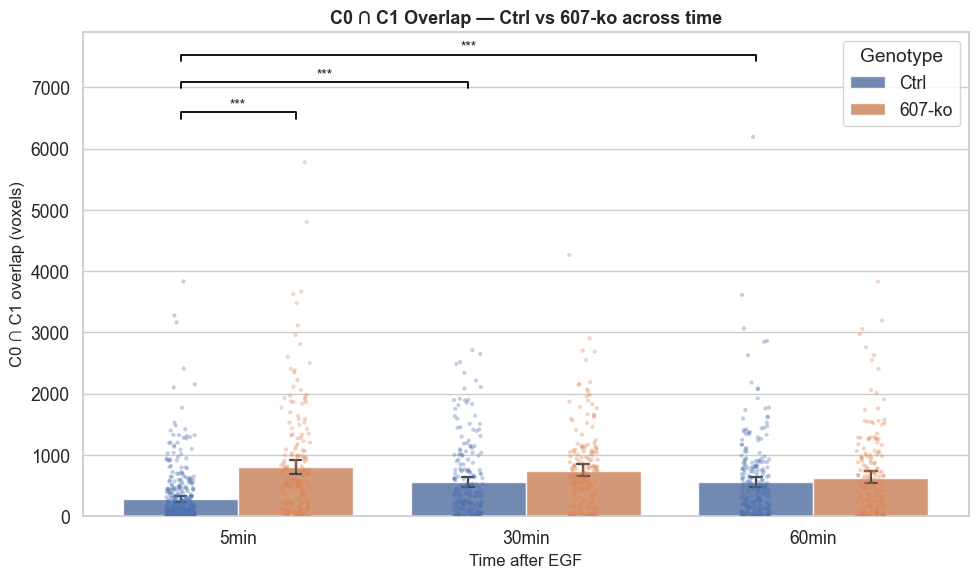

Saved → figures/timecourse_c0_c1.png


In [37]:
plot_overlap_combined(
    cells, 'c0_c1_overlap_voxels',
    ylabel='C0 ∩ C1 overlap (voxels)',
    title='C0 ∩ C1 Overlap — Ctrl vs 607-ko across time',
    fname='timecourse_c0_c1.png',
    bonf_df=bonf_c01
)

### 9b · C0 ∩ C2 — change over time

In [38]:
bonf_c02 = overlap_timecourse_table(cells, 'c0_c2_overlap_voxels', 'C0 ∩ C2 Overlap (voxels)')


  C0 ∩ C2 Overlap (voxels)

  Two-way ANOVA (genotype × timepoint):


,Source,SS,DF,MS,F,p_unc,np2
0,genotype,1.356850e+05,1.0,135684.9895,86.1371,0.0000,0.0551
1,timepoint,9.305408e+03,2.0,4652.7043,2.9537,0.0525,0.0040
2,genotype * timepoint,1.738668e+03,2.0,869.3339,0.5519,0.5760,0.0007
3,Residual,2.328176e+06,1478.0,1575.2207,NaN,NaN,NaN



  [Ctrl]  F(2, 891) = 5.759,  p = 0.0033  **
  [607-ko]  F(2, 587) = 0.353,  p = 0.7024  ns

  Bonferroni pairwise — all 6 groups:


,A,B,mean(A),mean(B),Δ mean,T,dof,p_unc,p_corr,sig,pair_type
0,607-ko 5min,Ctrl 5min,37.7,15.6,22.1,5.3150,252.6870,0.0000,0.0000,***,same-timepoint
1,607-ko 30min,Ctrl 30min,39.7,23.0,16.7,4.1957,325.3647,0.0000,0.0005,***,same-timepoint
2,607-ko 60min,Ctrl 60min,35.2,15.7,19.5,4.6521,255.4695,0.0000,0.0001,***,same-timepoint
3,607-ko 5min,Ctrl 30min,37.7,23.0,14.7,3.2949,309.0890,0.0011,0.0165,*,cross
4,607-ko 5min,607-ko 60min,37.7,35.2,2.5,0.4492,396.9660,0.6535,1.0000,ns,within-genotype
5,607-ko 5min,Ctrl 60min,37.7,15.7,22.0,5.2523,259.4938,0.0000,0.0000,***,cross
6,Ctrl 5min,Ctrl 60min,15.6,15.7,-0.1,-0.0325,617.4323,0.9741,1.0000,ns,within-genotype
7,607-ko 30min,607-ko 5min,39.7,37.7,2.0,0.3847,383.8216,0.7007,1.0000,ns,within-genotype
8,607-ko 30min,Ctrl 5min,39.7,15.6,24.1,6.6198,258.5729,0.0000,0.0000,***,cross
9,Ctrl 30min,Ctrl 5min,23.0,15.6,7.4,2.9393,409.2024,0.0035,0.0521,ns,within-genotype


  Saved → timecourse_c0_c2_overlap_voxels.csv


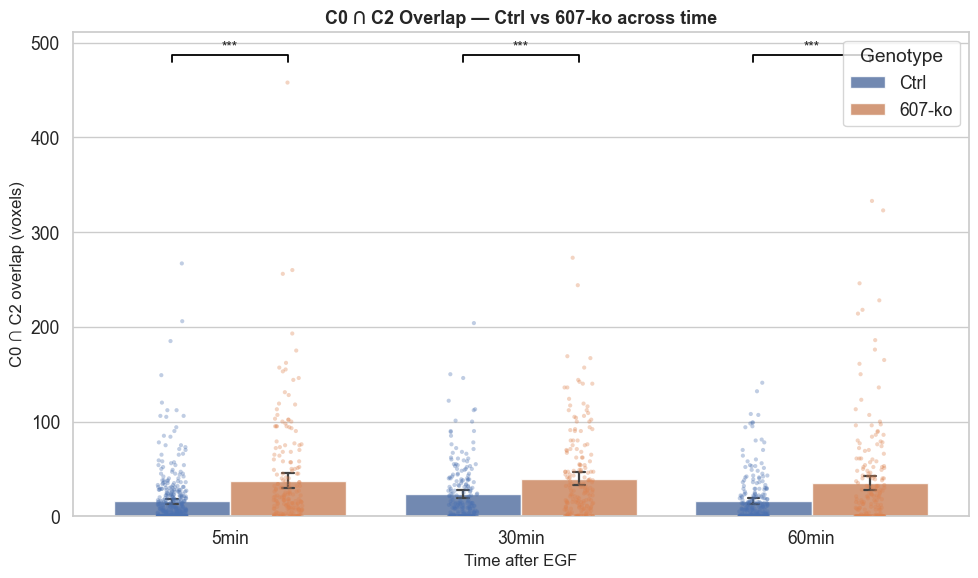

Saved → figures/timecourse_c0_c2.png


In [39]:
plot_overlap_combined(
    cells, 'c0_c2_overlap_voxels',
    ylabel='C0 ∩ C2 overlap (voxels)',
    title='C0 ∩ C2 Overlap — Ctrl vs 607-ko across time',
    fname='timecourse_c0_c2.png',
    bonf_df=bonf_c02
)

### 9c · C1 ∩ C2 — change over time

In [40]:
bonf_c12 = overlap_timecourse_table(cells, 'c1_c2_overlap_voxels', 'C1 ∩ C2 Overlap (voxels)')


  C1 ∩ C2 Overlap (voxels)

  Two-way ANOVA (genotype × timepoint):


,Source,SS,DF,MS,F,p_unc,np2
0,genotype,4.771981e+06,1.0,4.771981e+06,80.0764,0.0,0.0514
1,timepoint,2.872043e+07,2.0,1.436022e+07,240.9722,0.0,0.2459
2,genotype * timepoint,1.917207e+06,2.0,9.586036e+05,16.0859,0.0,0.0213
3,Residual,8.807819e+07,1478.0,5.959282e+04,NaN,NaN,NaN



  [Ctrl]  F(2, 891) = 186.917,  p = 0.0000  ***
  [607-ko]  F(2, 587) = 89.969,  p = 0.0000  ***

  Bonferroni pairwise — all 6 groups:


,A,B,mean(A),mean(B),Δ mean,T,dof,p_unc,p_corr,sig,pair_type
0,607-ko 5min,Ctrl 5min,65.7,20.3,45.4,7.4343,242.9326,0.0000,0.0000,***,same-timepoint
1,607-ko 30min,Ctrl 30min,448.9,223.1,225.8,7.5137,299.5358,0.0000,0.0000,***,same-timepoint
2,607-ko 60min,Ctrl 60min,397.0,293.2,103.8,3.1788,349.1806,0.0016,0.0242,*,same-timepoint
3,607-ko 5min,Ctrl 30min,65.7,223.1,-157.4,-10.0458,284.0066,0.0000,0.0000,***,cross
4,607-ko 5min,607-ko 60min,65.7,397.0,-331.3,-11.7993,214.6282,0.0000,0.0000,***,within-genotype
5,607-ko 5min,Ctrl 60min,65.7,293.2,-227.5,-12.2117,316.8162,0.0000,0.0000,***,cross
6,Ctrl 5min,Ctrl 60min,20.3,293.2,-272.9,-15.3361,267.9588,0.0000,0.0000,***,within-genotype
7,607-ko 30min,607-ko 5min,448.9,65.7,383.2,14.2283,208.5607,0.0000,0.0000,***,within-genotype
8,607-ko 30min,Ctrl 5min,448.9,20.3,428.6,16.2584,191.9548,0.0000,0.0000,***,cross
9,Ctrl 30min,Ctrl 5min,223.1,20.3,202.8,13.8265,224.3124,0.0000,0.0000,***,within-genotype


  Saved → timecourse_c1_c2_overlap_voxels.csv


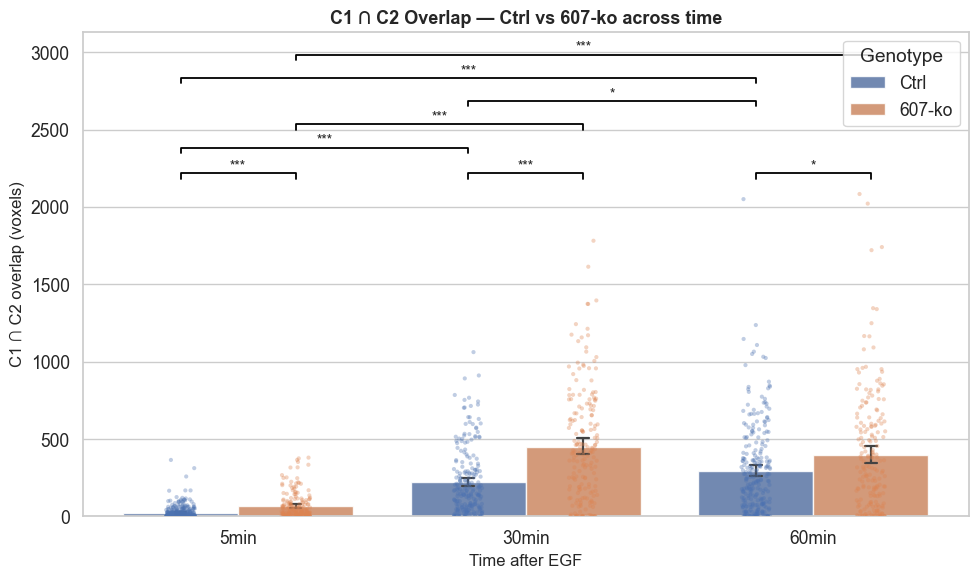

Saved → figures/timecourse_c1_c2.png


In [41]:
plot_overlap_combined(
    cells, 'c1_c2_overlap_voxels',
    ylabel='C1 ∩ C2 overlap (voxels)',
    title='C1 ∩ C2 Overlap — Ctrl vs 607-ko across time',
    fname='timecourse_c1_c2.png',
    bonf_df=bonf_c12
)